In [33]:
# Imports 
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Additional 
!pip install openpyxl

In [55]:
# Data
df_trade = pd.read_csv(r"D:\Python\france-battery-trade-analysis\data\france_battery_trade.csv")
df_gbard_nabs = pd.read_excel(r"D:\Python\france-battery-trade-analysis\data\GBARD_socioeco_obj.xlsx")
df_berd = pd.read_csv(r"D:\Python\france-battery-trade-analysis\data\BERD_NACE_activity_source_fund.csv")

D:\projects\france-battery-trade-analysis\venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning:

Workbook contains no default style, apply openpyxl's default



In [56]:
# Inspection
print(df_trade.head())
print(df_gbard_nabs.head())
print(df_berd.head())

  STRUCTURE          STRUCTURE_ID  \
0  dataflow  ESTAT:DS-059341(1.0)   
1  dataflow  ESTAT:DS-059341(1.0)   
2  dataflow  ESTAT:DS-059341(1.0)   
3  dataflow  ESTAT:DS-059341(1.0)   
4  dataflow  ESTAT:DS-059341(1.0)   

                                      STRUCTURE_NAME freq Frequency reporter  \
0  International trade of EU and non-EU countries...    A    Annual       FR   
1  International trade of EU and non-EU countries...    A    Annual       FR   
2  International trade of EU and non-EU countries...    A    Annual       FR   
3  International trade of EU and non-EU countries...    A    Annual       FR   
4  International trade of EU and non-EU countries...    A    Annual       FR   

                                            REPORTER partner PARTNER product  \
0  France (incl. Saint Barthélemy 'BL' -> 2012; i...      CN   China  850710   
1  France (incl. Saint Barthélemy 'BL' -> 2012; i...      CN   China  850710   
2  France (incl. Saint Barthélemy 'BL' -> 2012; i...    

In [57]:
# Anticipating duplicates
print(df_trade.columns)
print(df_trade.columns.duplicated())

Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Frequency',
       'reporter', 'REPORTER', 'partner', 'PARTNER', 'product', 'PRODUCT',
       'flow', 'FLOW', 'indicators', 'INDICATORS', 'TIME_PERIOD',
       'TIME_PERIOD.1', 'OBS_VALUE', 'Observation Value'],
      dtype='object')
[False False False False False False False False False False False False
 False False False False False False False]


In [58]:
# Removing duplicates
df_trade = df_trade.loc[:, ~df_trade.columns.duplicated()]
print(df_trade.columns)

Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Frequency',
       'reporter', 'REPORTER', 'partner', 'PARTNER', 'product', 'PRODUCT',
       'flow', 'FLOW', 'indicators', 'INDICATORS', 'TIME_PERIOD',
       'TIME_PERIOD.1', 'OBS_VALUE', 'Observation Value'],
      dtype='object')


In [60]:
# Cleaning data

# Asian focus
partners = ['CN','JP','KR','SG','TW','VN']

# Remove duplicates
df_trade = df_trade.loc[:, ~df_trade.columns.duplicated()]

# Standardize column names
df_trade.columns = df_trade.columns.str.lower()
df_gbard_nabs.columns = df_gbard_nabs.columns.str.lower().str.strip()
df_berd.columns = df_berd.columns.str.lower().str.strip()

# Filter for relevant partners and battery products
df_trade_filtered = df_trade[
    (df_trade['partner'].isin(partners)) &
    (df_trade['product'].astype(str).str.startswith('8507'))
].copy()

# Convert flow to numeric and map to ype
df_trade_filtered['flow'] = pd.to_numeric(df_trade_filtered['flow'].astype(str), errors='coerce')
df_trade_filtered['flow_type'] = df_trade_filtered['flow'].map({1:'Import', 2:'Export'})

# Convert years and drop invalid
df_trade_filtered['time_period'] = pd.to_numeric(df_trade_filtered['time_period'], errors='coerce')
df_trade_filtered = df_trade_filtered.dropna(subset=['time_period'])
df_trade_filtered['time_period'] = df_trade_filtered['time_period'].astype(int)
df_trade_filtered.sort_values('time_period', inplace=True)

# Aggregate obs_value in case of duplicates
trade_summary = df_trade_filtered.groupby(['partner','flow_type','time_period'])['obs_value'].sum().reset_index()

trade_summary.head()

,partner,flow_type,time_period,obs_value
0,CN,Export,2002,2475085
1,CN,Export,2003,4081143
2,CN,Export,2004,4409120
3,CN,Export,2005,2251925
4,CN,Export,2006,4371102


In [61]:
# Analysis 1: trade trends

# Total trade per partner and flow
trade_summary = df_trade_filtered.groupby(['partner','flow_type','time_period'])['obs_value'].sum().reset_index()

# Pivot table for line chart
trade_pivot = trade_summary.pivot_table(
    index='time_period',
    columns=['partner','flow_type'],
    values='obs_value',
    fill_value=0
)

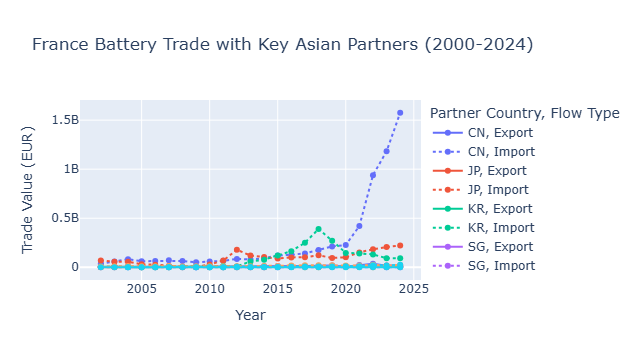

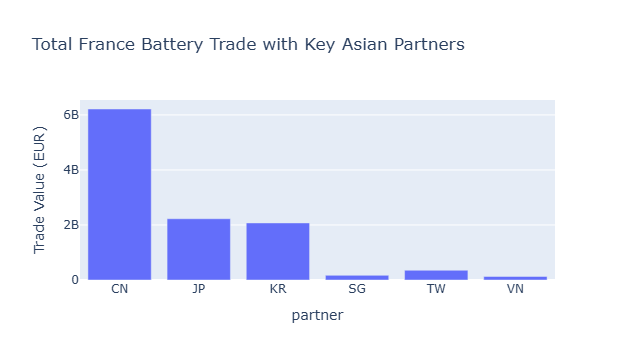

In [62]:
# Visualization

# Line chart showing imports/exports over time per partner
fig_trade = px.line(
    trade_summary,
    x='time_period',
    y='obs_value',
    color='partner',      # <-- ensures each partner has its own line
    line_dash='flow_type',# optional: different dash for Import/Export
    markers=True,
    title='France Battery Trade with Key Asian Partners (2000-2024)',
    labels={
        'time_period':'Year',
        'obs_value':'Trade Value (EUR)',
        'partner':'Partner Country',
        'flow_type':'Flow Type'
    }
)

fig_trade.show()

# Bar chart of total trade by partner
total_trade = trade_summary.groupby('partner')['obs_value'].sum().reset_index()
fig_bar = px.bar(
    total_trade,
    x='partner',
    y='obs_value',
    title='Total France Battery Trade with Key Asian Partners',
    labels={'obs_value':'Trade Value (EUR)'}
)
fig_bar.show()

In [63]:
# Analysis 2: Innovation inputs

D:\projects\france-battery-trade-analysis\venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning:

Workbook contains no default style, apply openpyxl's default

D:\projects\france-battery-trade-analysis\venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning:

Workbook contains no default style, apply openpyxl's default

D:\projects\france-battery-trade-analysis\venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning:

Workbook contains no default style, apply openpyxl's default

D:\projects\france-battery-trade-analysis\venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning:

Workbook contains no default style, apply openpyxl's default



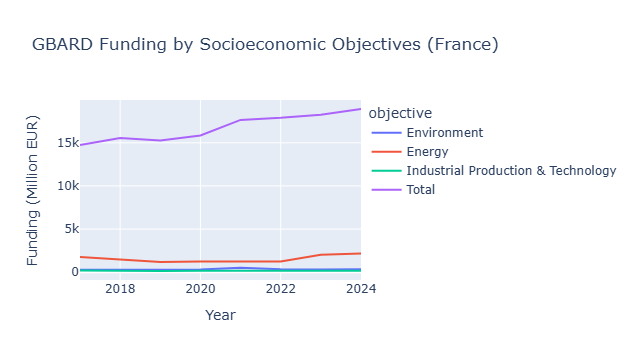

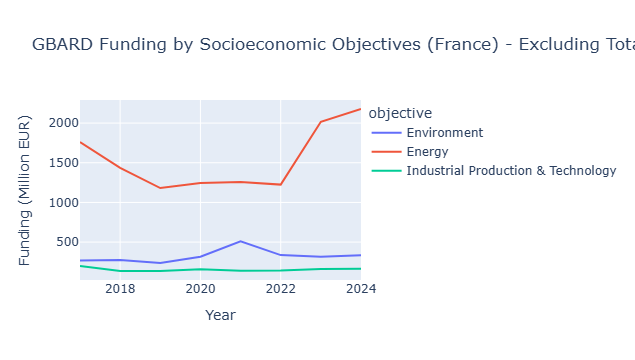

In [83]:
# GBARD: socioeconomic objectives (energy, industrial production, environment, total R&D expenditure)

file_path = r'D:\Python\france-battery-trade-analysis\data\GBARD_socioeco_obj.xlsx'

# Sheets 1–4 correspond to socioeconomic objectives
sheets = {1: 'Environment', 2: 'Energy', 3: 'Industrial Production & Technology', 4: 'Total'}

nabs_list = []

for sheet_idx, objective in sheets.items():
    # Read sheet without headers
    df_sheet = pd.read_excel(file_path, sheet_name=sheet_idx, header=None)
    
    # Extract years from line 9 (0-indexed row 8), skip first column (labels)
    year_row = df_sheet.iloc[8, 1:]
    years = []
    for val in year_row:
        try:
            years.append(int(val))
        except:
            continue  # skip non-numeric cells

    # Extract France row from line 11 (0-indexed row 10), skip first column
    france_row = df_sheet.iloc[10, 1:]
    funds = []
    for val in france_row:
        if pd.isna(val):
            continue
        # Remove flags, commas, etc.
        val_str = str(val).replace(',', '').replace('e','').replace(':','').strip()
        try:
            funds.append(float(val_str))
        except:
            continue

    # Ensure years and funds have same length
    if len(funds) > len(years):
        funds = funds[:len(years)]
    
    # Build DataFrame
    df_long = pd.DataFrame({'time_period': years[:len(funds)], 'funds': funds})
    df_long['objective'] = objective
    nabs_list.append(df_long)

# Combine all objectives
df_nabs_combined = pd.concat(nabs_list, ignore_index=True)

# Plot
fig_nabs = px.line(
    df_nabs_combined,
    x='time_period',
    y='funds',
    color='objective',
    title='GBARD Funding by Socioeconomic Objectives (France)',
    labels={'time_period': 'Year', 'funds': 'Funding (Million EUR)'}
)
fig_nabs.show()

# Filter out the 'Total' objective
df_nabs_no_total = df_nabs_combined[df_nabs_combined['objective'] != 'Total']

# Plot line chart without total
fig_nabs_no_total = px.line(
    df_nabs_no_total,
    x='time_period',
    y='funds',
    color='objective',
    title='GBARD Funding by Socioeconomic Objectives (France) - Excluding Total',
    labels={'time_period': 'Year', 'funds': 'Funding (Million EUR)'}
)
fig_nabs_no_total.show()

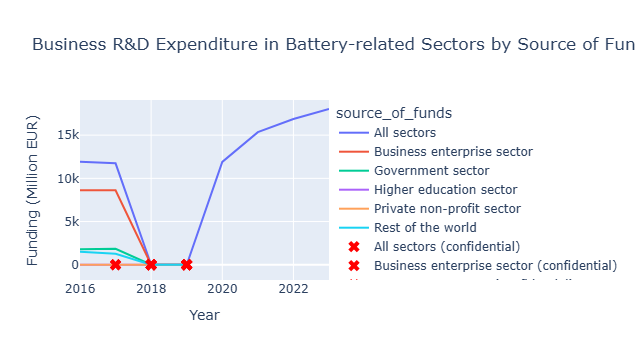

In [95]:
# BERD: by sector and source of funds

import numpy as np

# Standardize column names
df_berd.columns = df_berd.columns.str.lower().str.strip().str.replace(' ', '_')

# Focus on battery-relevant sector
df_berd_focus = df_berd[df_berd['nace_r2'] == 'C25-C30'].copy()

# Clean obs_value: remove letters, flags, handle empty strings
df_berd_focus['obs_value'] = (
    df_berd_focus['obs_value']
    .astype(str)                       # ensure string
    .str.replace(r'[^\d.,-]', '', regex=True)  # remove letters, flags
    .str.replace(',', '', regex=False)        # remove commas
    .replace('', np.nan)                        # replace empty string with NaN
    .astype(float)                              # convert to float
)

# Create a flag for confidential/missing values
df_berd_focus['confidential'] = df_berd_focus['obs_value'].isna()

# Group by source_of_funds and time_period
berd_summary = df_berd_focus.groupby(['source_of_funds', 'time_period'])['obs_value'].sum().reset_index()

# Add confidential flag after grouping
berd_summary = berd_summary.merge(
    df_berd_focus.groupby(['source_of_funds', 'time_period'])['confidential'].any().reset_index(),
    on=['source_of_funds', 'time_period']
)

# Plot
fig_berd = px.line(
    berd_summary,
    x='time_period',
    y='obs_value',
    color='source_of_funds',
    title='Business R&D Expenditure in Battery-related Sectors by Source of Funds',
    labels={'obs_value': 'Funding (Million EUR)', 'time_period': 'Year'}
)

# Add markers where data is confidential
for source in berd_summary['source_of_funds'].unique():
    df_source = berd_summary[berd_summary['source_of_funds'] == source]
    df_conf = df_source[df_source['confidential']]
    fig_berd.add_scatter(
        x=df_conf['time_period'],
        y=df_conf['obs_value'],
        mode='markers',
        marker=dict(symbol='x', size=10, color='red'),
        name=f'{source} (confidential)',
        showlegend=True
    )

fig_berd.show()


Observation on previous graph: From 2018 to 2019, BERD data for battery-relevant sectors is largely confidential, with no public values available for specific industries as marked by the crosses on the above chart. Only aggregated data for "All sectors" is reported after 2019. This explains why individual sector lines do not appear in the graph for those years.

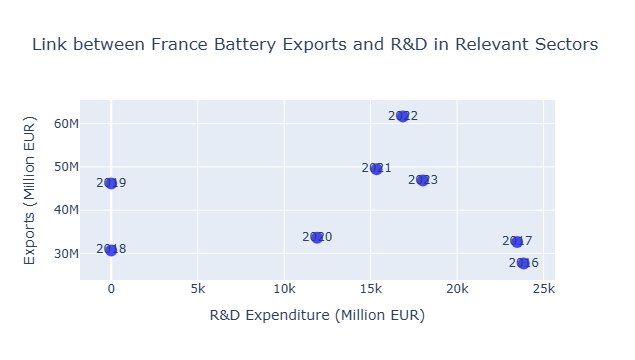

In [94]:
# Final insights: Trade and Innovation
# Exports and R&D correlation
trade_exports = trade_summary[trade_summary['flow_type']=='Export'].groupby('time_period')['obs_value'].sum().reset_index()
berd_total = berd_summary.groupby('time_period')['obs_value'].sum().reset_index()

combined = pd.merge(trade_exports, berd_total, on='time_period', suffixes=('_trade','_r&d'))

# Scatter plot: France Battery Exports vs. R&D Expenditure
fig_scatter = px.scatter(
    combined,
    x='obs_value_r&d',
    y='obs_value_trade',
    text='time_period',
    title='Link between France Battery Exports and R&D in Relevant Sectors',
    labels={'obs_value_r&d':'R&D Expenditure (Million EUR)','obs_value_trade':'Exports (Million EUR)'},
    hover_data={'time_period':True, 'obs_value_r&d':':,.0f', 'obs_value_trade':':,.0f'}
)
fig_scatter.update_traces(marker=dict(size=12, color='blue', opacity=0.7))
fig_scatter.show()

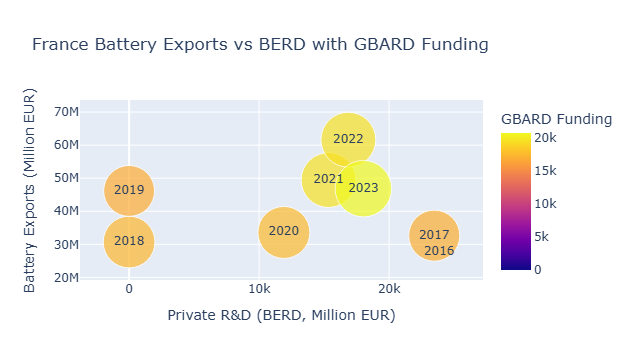

In [97]:
# --- Prepare combined data ---
combined = pd.merge(trade_exports, berd_total, on='time_period', suffixes=('_trade','_r&d'))

# Add GBARD total funding per year
gbard_total = df_nabs_combined.groupby('time_period')['funds'].sum().reset_index()
combined = pd.merge(combined, gbard_total, on='time_period', how='left')
combined.rename(columns={'funds': 'gbard_funding'}, inplace=True)

# Replace NaN GBARD values with 0 for plotting
combined['gbard_funding'] = combined['gbard_funding'].fillna(0)

# --- Scatter plot ---
fig = px.scatter(
    combined,
    x='obs_value_r&d',          # BERD
    y='obs_value_trade',        # Exports
    size='gbard_funding',       # GBARD as marker size
    color='gbard_funding',      # GBARD also as color gradient
    text='time_period',         # annotate points with year
    title='France Battery Exports vs BERD with GBARD Funding',
    labels={
        'obs_value_r&d': 'Private R&D (BERD, Million EUR)',
        'obs_value_trade': 'Battery Exports (Million EUR)',
        'gbard_funding': 'GBARD Funding (Million EUR)'
    },
    size_max=40
)

fig.update_traces(marker=dict(opacity=0.7), selector=dict(mode='markers+text'))
fig.update_layout(coloraxis_colorbar=dict(title="GBARD Funding"))

fig.show()

Conclusion:

The data story for France’s battery ecosystem reveals a clear narrative:
- Government budget allocations for R&D (GBARD) underlie a long‑term strategic focus on Environment, Energy and Industrial Production & Technology.  
- Business R&D expenditure in battery‑relevant sectors (BERD) remained constrained until roughly 2020, after which it shows a meaningful rebound — suggesting that public funding helped ignite private investment.  
- France’s battery exports rise in tandem with R&D and innovation spending, illustrating the policy‑to‑industry‑to‑trade pipeline.  
- Nonetheless, tensions emerge: sector‑specific reporting gaps (2018‑19 confidentiality), dependence on Asian supply chains (especially batteries and EVs) and the need to reconcile open trade with industrial resilience.
   
For a city‑oriented inclusive development lens: the local impact of battery factories, skills development, supply‑chain anchoring and export growth all tie back into the national innovation strategy.  

These findings set the stage for a deeper Substack article exploring the geopolitics of green re‑industrialisation, trade dependencies, industrial policy and inclusive urban/regional development in France and Europe.